# Kmeans operating Conditions (Betriebszustände)
- Wichtiger fachlicher Punkt vorab: Da es sich um Zählerstände handelt, sind Energy (kWh) und Volume (m³) vermutlich kumulierte Register (aufsummiert seit Inbetriebnahme), während Power, Volume flow, Temperature difference, Flow/Return temperature bereits Momentanwerte sind. Für sinnvolle Betriebszustände darf man kumulierte Zähler nicht direkt clustern

Die real_meter datein die im notebook 00 erstellt werden werden hier rein geladen.

In [1]:
import glob
import os
import re
import pandas as pd

# Pfad zu deinen Daten anpassen (Ordner mit allen HASt-CSV-Dateien)
input_pattern = r"C:\Users\pauli\Documents\Information Systems\2026 SoSe\Projektseminar\projektseminar-1\data\processed\real_meters\*.csv"

# Encoding-Fix für "Â°C" -> "°C" (doppelt kodiertes UTF-8)
def fix_mojibake(text: str) -> str:
    return (text.replace("Â°C", "°C")
                .replace("Â³", "³")
                .replace("Â²", "²"))

def load_one_file(path: str) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "latin1", "cp1252"):
        try:
            df = pd.read_csv(path, encoding=enc, sep=None, engine="python")
            break
        except (UnicodeDecodeError, pd.errors.ParserError):
            continue
    else:
        raise ValueError(f"Konnte {path} mit keinem bekannten Encoding lesen.")

    df.columns = [fix_mojibake(c).strip() for c in df.columns]

    # HASt-ID aus Dateiname ableiten
    stem = os.path.splitext(os.path.basename(path))[0]
    df["HASt_ID"] = re.sub(r"[^A-Za-z0-9_\-]", "_", stem)
    return df

files = sorted(glob.glob(input_pattern))
print(f"{len(files)} Dateien gefunden")

frames = [load_one_file(f) for f in files]
df_raw = pd.concat(frames, ignore_index=True)

print(df_raw.shape)
df_raw.head()

101 Dateien gefunden
(2513880, 9)


,Timestamp,Energy (kWh),Volume flow (l/h),Power (kW),Temperature difference (°C),Flow temperature (°C),Return temperature (°C),Volume (m³),HASt_ID
0,2021-11-01 23:00:00,4170965.0,0.0,0.0,4.1,62.1,58.0,187515.46,41566330
1,2021-11-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41566330
2,2021-11-02 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41566330
3,2021-11-02 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41566330
4,2021-11-02 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41566330


Wir wollen nach Stunden clustern, also droppen wir alle Zeilen die keine Einträge haben, um nur die Stunden zu clustern für die wir Werte haben.
Fraglich ist, wenn wir alle stunden clusten können wir dann Betriebszustände erkennen oder nur Jahreszeiten? 
Werden aufeinander folgende Stunden in die selben Cluster eingeordnet?

In [2]:
df_clean = df_raw.dropna()
df_clean.head()

,Timestamp,Energy (kWh),Volume flow (l/h),Power (kW),Temperature difference (°C),Flow temperature (°C),Return temperature (°C),Volume (m³),HASt_ID
0,2021-11-01 23:00:00,4170965.0,0.0,0.0,4.1,62.1,58.0,187515.46,41566330
24,2021-11-02 23:00:00,4174407.0,0.0,0.0,2.9,60.6,57.7,187670.41,41566330
48,2021-11-03 23:00:00,4174558.0,0.0,0.0,10.7,75.7,64.9,187678.47,41566330
72,2021-11-04 23:00:00,4174558.0,0.0,0.0,14.5,72.8,58.4,187678.47,41566330
96,2021-11-05 23:00:00,4177643.0,0.0,0.0,4.2,62.6,58.4,187803.37,41566330


In [3]:
df_clean.tail(10)

,Timestamp,Energy (kWh),Volume flow (l/h),Power (kW),Temperature difference (°C),Flow temperature (°C),Return temperature (°C),Volume (m³),HASt_ID
2513870,2025-07-11 04:00:00,1856525.0,16334.0,179.275,9.7,84.0,74.3,107220.63,86792512
2513871,2025-07-11 05:00:00,1856689.0,16505.0,204.102,10.8,82.6,71.8,107237.31,86792512
2513872,2025-07-11 06:00:00,1856878.0,16550.0,259.245,13.6,81.2,67.6,107253.96,86792512
2513873,2025-07-11 07:00:00,1857104.0,16676.0,208.044,10.9,83.7,72.8,107270.69,86792512
2513874,2025-07-11 08:00:00,1857311.0,16469.0,216.769,11.5,82.6,71.0,107287.41,86792512
2513875,2025-07-11 09:00:00,1857534.0,16388.0,225.366,12.1,82.4,70.3,107304.12,86792512
2513876,2025-07-11 10:00:00,1857765.0,16523.0,209.366,11.0,83.1,72.1,107320.83,86792512
2513877,2025-07-11 11:00:00,1857959.0,16776.0,171.905,8.8,84.5,75.7,107337.53,86792512
2513878,2025-07-11 12:00:00,1858146.0,17045.0,198.212,9.9,83.6,73.7,107354.24,86792512
2513879,2025-07-11 13:00:00,1858363.0,16577.0,242.000,12.7,81.7,69.0,107370.95,86792512


Hier plotten wir einmal alle HAST Leistungen entlag einer Zeitachse. Um zu verdeutlichen wie viele Daten es gibt.

In [4]:
import matplotlib.pyplot as plt

# Spalte, die geplottet werden soll (anpassen)
value_col = "Power (kW)"

fig, ax = plt.subplots(figsize=(14, 6))

for hast_id, group in df_clean.groupby("HASt_ID"):
    ax.plot(group["Timestamp"], group[value_col], label=hast_id, linewidth=0.8)

ax.set_xlabel("Zeit")
ax.set_ylabel(value_col)
ax.set_title(f"{value_col} im Zeitverlauf – alle HASts")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=7)  # Legende außerhalb, sonst zu voll
plt.tight_layout()
plt.show()

C:\Users\pauli\AppData\Local\Temp\ipykernel_13404\271162243.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


KeyboardInterrupt: 

Im nächsten schritt wollen wir HASTs die fast konstant im stillstand sind entfernen, damit sie unsere Ergebnisse nicht verzerren.

In [5]:
print(df_clean["Power (kW)"].dtype)
print(df_clean["Power (kW)"].describe())
print(df_clean.groupby("HASt_ID")["Power (kW)"].quantile(0.95).describe())


float64
count    1.729047e+06
mean     4.917568e+00
std      2.346118e+01
min     -1.999540e+02
25%      0.000000e+00
50%      5.130000e-01
75%      3.398000e+00
max      7.477420e+02
Name: Power (kW), dtype: float64
count     97.000000
mean      15.545697
std       41.086134
min        0.000000
25%        4.666000
50%        6.811750
75%        9.726000
max      286.377000
Name: Power (kW), dtype: float64


In [7]:
# 3 HASTs sind im 95% der zeit ohne Power und Volume Flow, diese werden raus gefiltert bis man weiß warum.
# HASts mit p95(Power) == 0 identifizieren und komplett entfernen
p95_power = df_clean.groupby("HASt_ID")["Power (kW)"].transform(lambda x: x.quantile(0.95))
hasts_zero = df_clean.loc[p95_power == 0, "HASt_ID"].unique()

print(f"Entferne {len(hasts_zero)} HASts: {list(hasts_zero)}")
print(f"Zeilen vorher: {len(df_clean)}")

df_clean = df_clean[~df_clean["HASt_ID"].isin(hasts_zero)].copy()

print(f"Zeilen nachher: {len(df_clean)}")

Entferne 0 HASts: []
Zeilen vorher: 1658002
Zeilen nachher: 1658002


In [8]:
# Normierung mit den Original-Spaltennamen (Leerzeichen/Klammern per Klammerzugriff)
for col in ["Power (kW)", "Volume flow (l/h)"]:
    p95 = df_clean.groupby("HASt_ID")[col].transform(lambda x: x.quantile(0.95))
    df_clean[f"{col}_norm"] = df_clean[col] / p95

feature_cols = [
    "Power (kW)_norm",
    "Volume flow (l/h)_norm",
    "Temperature difference (°C)",
    "Flow temperature (°C)",
    "Return temperature (°C)",
]

X = df_clean[feature_cols].dropna()
print(X.shape)

(1658002, 5)


In [9]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "Power (kW)_norm",
    "Volume flow (l/h)_norm",
    "Temperature difference (°C)",
    "Flow temperature (°C)",
    "Return temperature (°C)",
]

X = df_clean[feature_cols].dropna()
print(f"{len(X)} vollständige Datenpunkte")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

1658002 vollständige Datenpunkte


Nach dem wir Power und Volume normiert haben und alle Spalten standardisiert haben, finden wir nun das passende k mit der Elbow Method und Silhouette.

k=2: inertia=5715734.3, silhouette=0.310
k=3: inertia=3841163.8, silhouette=0.356
k=4: inertia=2668791.5, silhouette=0.397
k=5: inertia=2087211.5, silhouette=0.402
k=6: inertia=1822401.0, silhouette=0.383
k=7: inertia=1642718.0, silhouette=0.353


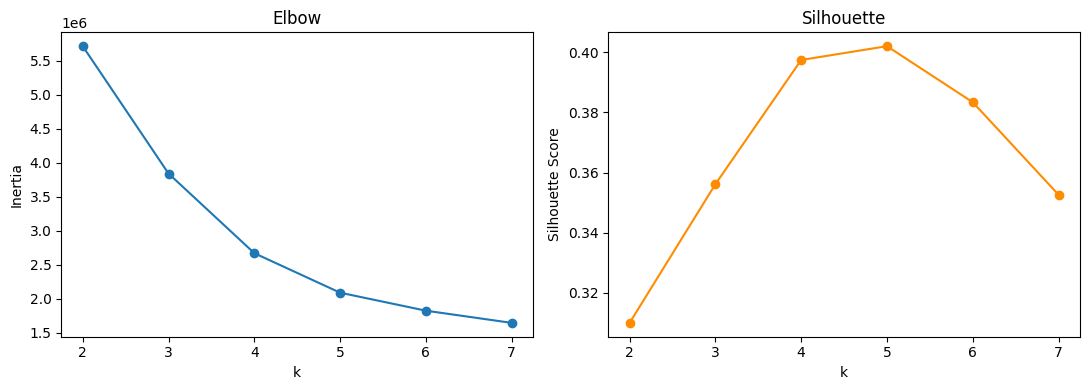

In [10]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 8)
inertias, silhouettes = [], []

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, n_init=3, random_state=42, batch_size=2048)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouettes.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

Wir clustern mit K=5

In [11]:
k = 5

km_final = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42, batch_size=2048)
X = X.copy()
X["cluster"] = km_final.fit_predict(X_scaled)

# Cluster-Zuordnung zurück ins Haupt-df mergen (über Index)
df_clean.loc[X.index, "cluster"] = X["cluster"]

df_clean[["HASt_ID", "Timestamp", "Power (kW)", "cluster"]].head(10)

,HASt_ID,Timestamp,Power (kW),cluster
0,41566330,2021-11-01 23:00:00,0.000,2.0
24,41566330,2021-11-02 23:00:00,0.000,2.0
48,41566330,2021-11-03 23:00:00,0.000,2.0
72,41566330,2021-11-04 23:00:00,0.000,2.0
96,41566330,2021-11-05 23:00:00,0.000,2.0
120,41566330,2021-11-06 23:00:00,179.074,4.0
144,41566330,2021-11-07 23:00:00,0.000,2.0
168,41566330,2021-11-08 23:00:00,0.000,2.0
192,41566330,2021-11-09 23:00:00,172.693,4.0
216,41566330,2021-11-10 23:00:00,190.582,4.0


In [12]:
import pandas as pd

centers_scaled = km_final.cluster_centers_
centers_orig = scaler.inverse_transform(centers_scaled)
centers_df = pd.DataFrame(centers_orig, columns=feature_cols)
centers_df["n_points"] = X["cluster"].value_counts().sort_index().values
centers_df["n_points_pct"] = (centers_df["n_points"] / len(X) * 100).round(1)

centers_df

,Power (kW)_norm,Volume flow (l/h)_norm,Temperature difference (°C),Flow temperature (°C),Return temperature (°C),n_points,n_points_pct
0,0.002014,0.013599,3.933108,37.378431,33.417338,336655,20.3
1,0.341125,0.225150,34.174899,67.326689,33.108246,408849,24.7
2,0.082950,0.112733,12.560851,67.579917,54.980115,408633,24.6
3,0.178632,0.793569,3.049273,75.264014,72.178626,195569,11.8
4,0.875386,0.849070,21.975676,73.867650,51.850840,308296,18.6


Besonders interessant: Cluster 3. Das ist fachlich der auffälligste Zustand – hoher Volumenstrom bei fast keiner Temperaturspreizung ist ein typisches Anzeichen für schlechte hydraulische Einbindung, defekte Regelventile oder Kurzschluss zwischen Vor- und Rücklauf an der HASt. Das würde ich mir gezielt anschauen: welche HASts landen wie oft in Cluster 3?

Wie oft hat jeder HAST cluster 3?

In [ ]:
df_clean[df_clean["cluster"] == 3]["HASt_ID"].value_counts().head(20)

HASt_ID
68956360     15772
72167782     15440
68956351     14389
80912182     14135
721354800    11916
72167793     11717
69513891     10919
68956372      9537
68956355      7651
72135480      7028
72167783      6031
72135453      5986
80912173      5262
72167777      4969
81062289      4482
66761022      4251
80912190      3873
72135442      3787
80912154      3713
68956356      3452
Name: count, dtype: int64

In [45]:
print(df_clean["Timestamp"].dtype)

str


In [46]:
df_clean["Timestamp"] = pd.to_datetime(df_clean["Timestamp"], errors="coerce")
print(df_clean["Timestamp"].dtype)  # sollte jetzt datetime64[ns] sein
print(df_clean["Timestamp"].isna().sum())  # prüfen ob dabei was zu NaT wurde

datetime64[us]
0


In [49]:
# 1. Datum extrahieren (nur einmal, vektorisiert)
df_clean["date"] = df_clean["Timestamp"].dt.floor("D")

# 2. Häufigkeit jedes Clusters pro HASt/Tag zählen (vektorisiert, schnell)
counts = df_clean.groupby(["HASt_ID", "date"])["cluster"].value_counts().unstack(fill_value=0)

# 3. Häufigsten Cluster pro Gruppe bestimmen
mode_cluster = counts.idxmax(axis=1)

df_daily = mode_cluster.reset_index(name="cluster")
df_daily.head()

,HASt_ID,date,cluster
0,41566330,2021-11-01,2.0
1,41566330,2021-11-02,2.0
2,41566330,2021-11-03,2.0
3,41566330,2021-11-04,2.0
4,41566330,2021-11-05,2.0


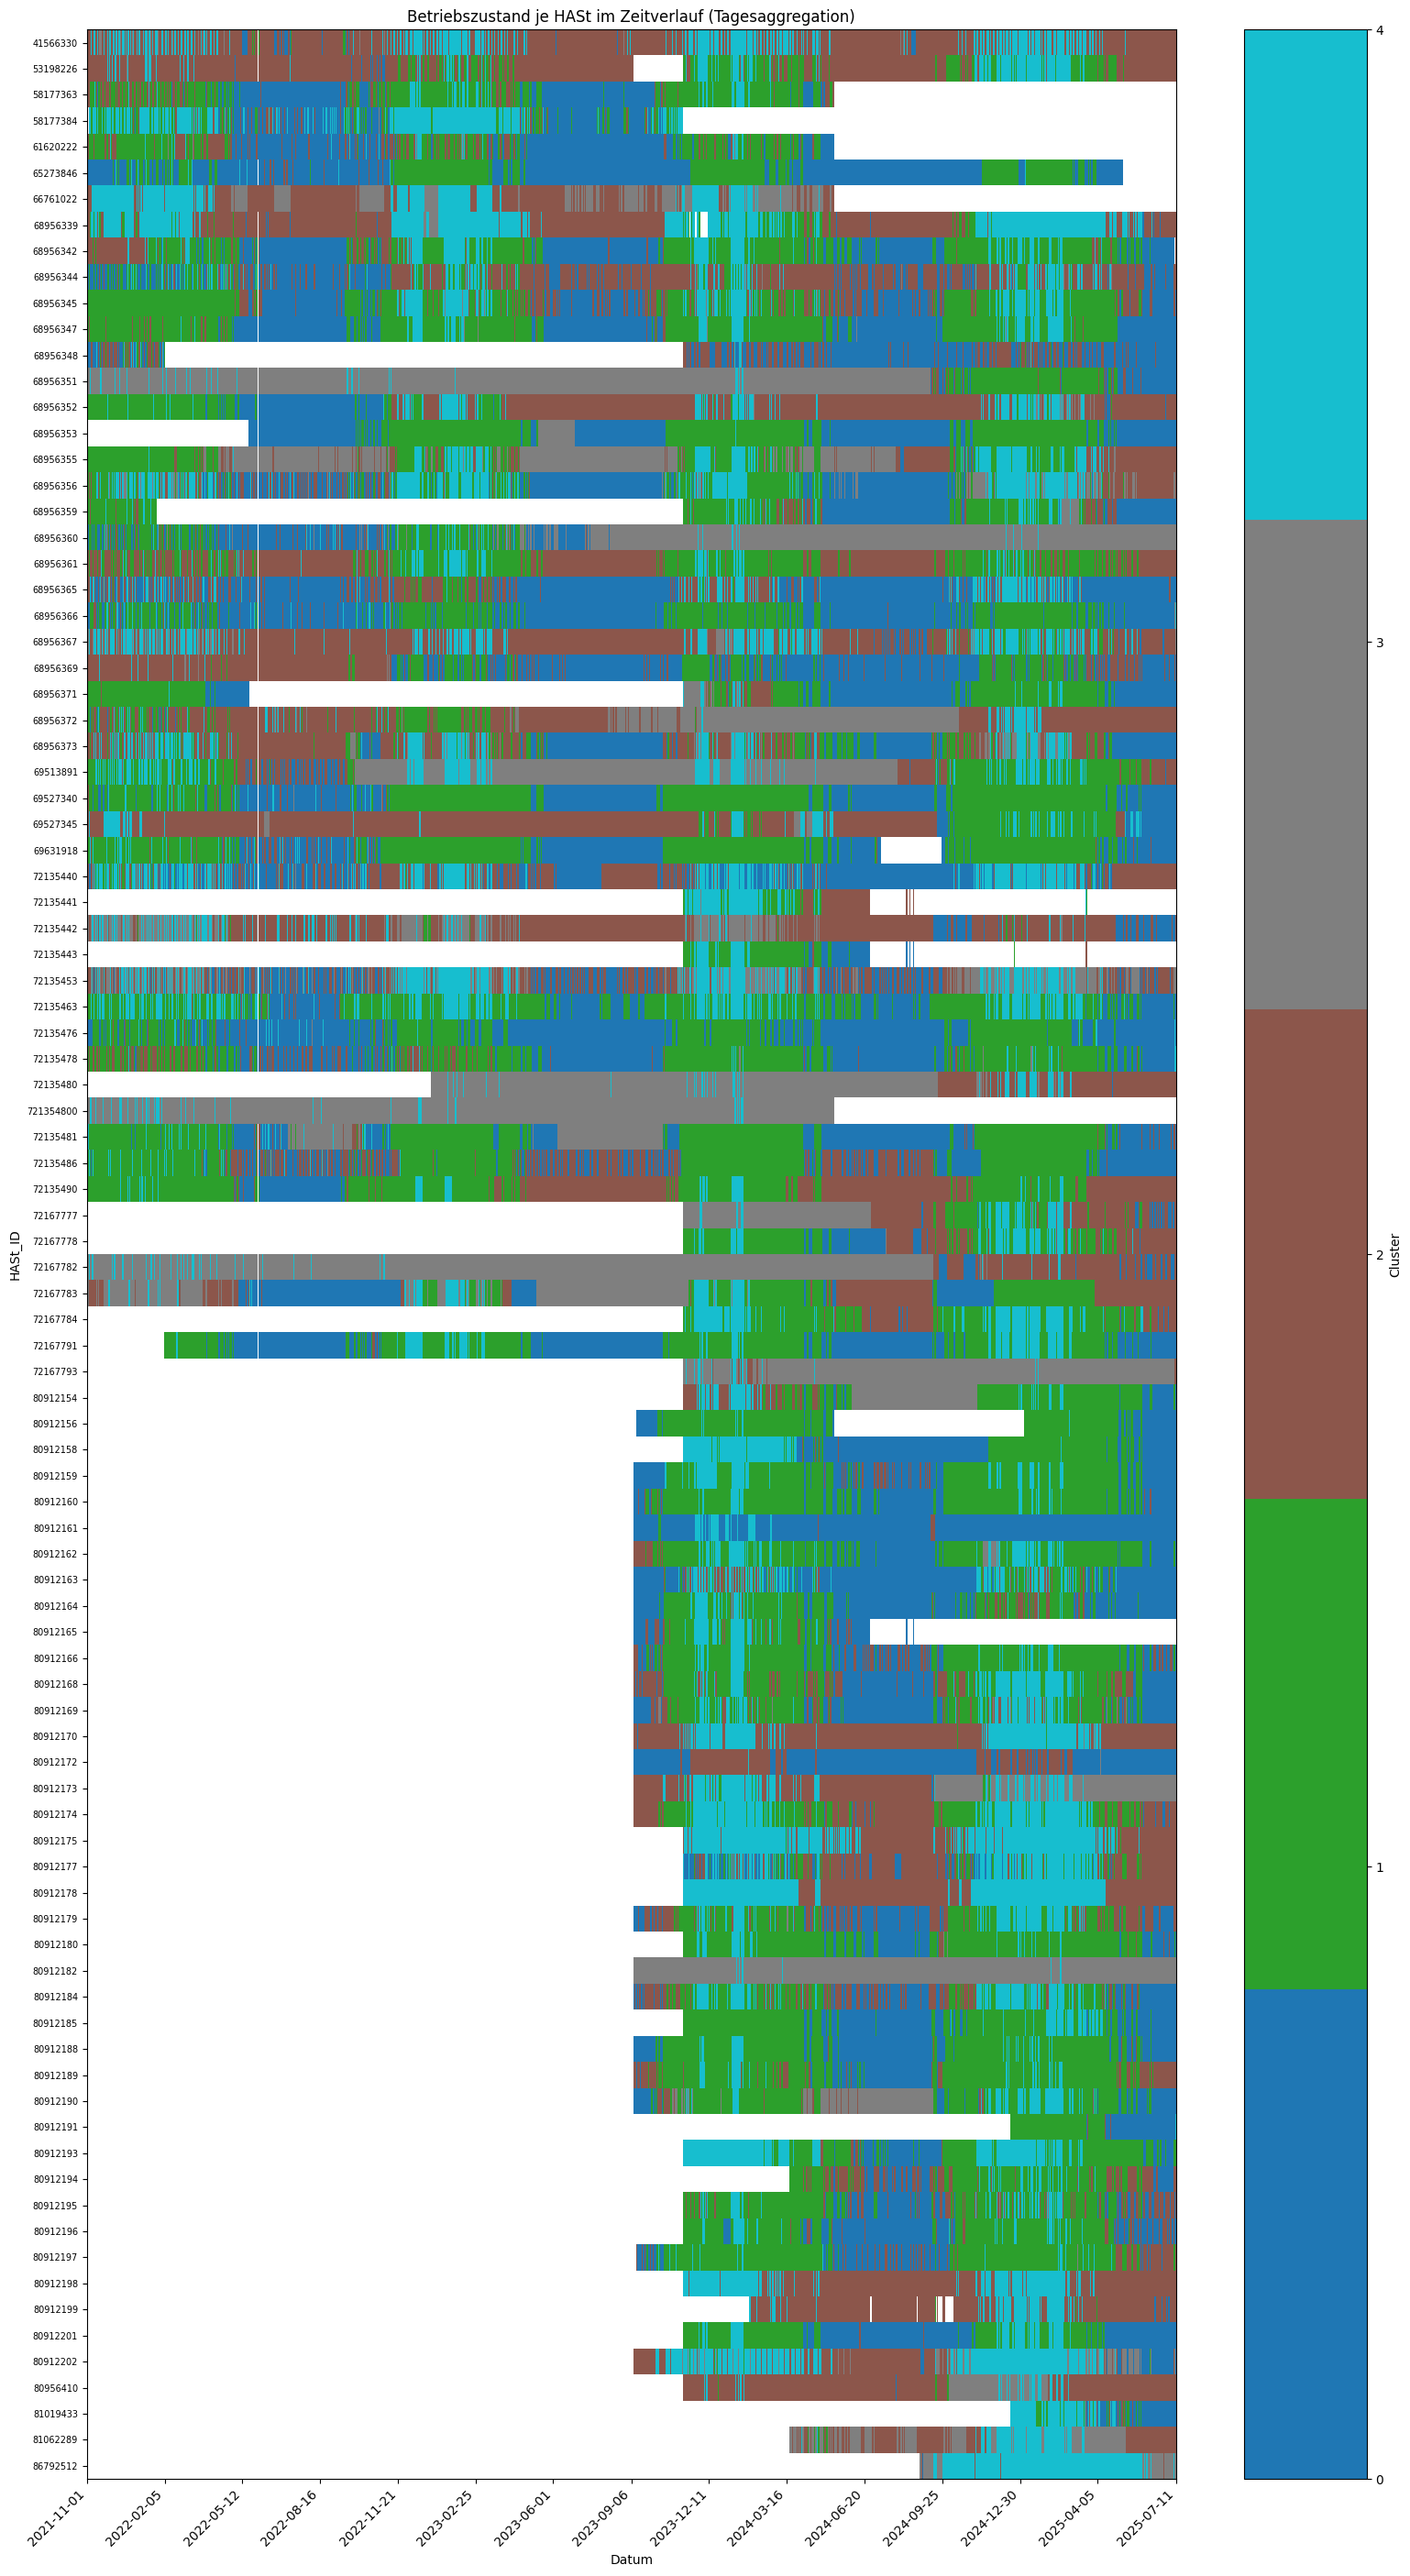

In [52]:
import numpy as np
import matplotlib.pyplot as plt

pivot = df_daily.pivot_table(index="HASt_ID", columns="date", values="cluster", aggfunc="first")

fig, ax = plt.subplots(figsize=(16, max(6, 0.3 * len(pivot))))

cmap = plt.get_cmap("tab10", k)
im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, interpolation="none")

# Echte Datumswerte auf x-Achse anzeigen (ca. 15 Ticks, lesbar verteilt)
n_dates = len(pivot.columns)
tick_positions = np.linspace(0, n_dates - 1, min(15, n_dates)).astype(int)
ax.set_xticks(tick_positions)
ax.set_xticklabels([pivot.columns[i].strftime("%Y-%m-%d") for i in tick_positions], rotation=45, ha="right")

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=7)
ax.set_xlabel("Datum")
ax.set_ylabel("HASt_ID")
ax.set_title("Betriebszustand je HASt im Zeitverlauf (Tagesaggregation)")

cbar = plt.colorbar(im, ax=ax, ticks=range(k))
cbar.set_label("Cluster")

plt.tight_layout()
plt.show()

Cluster 0 – Stillstand / Nulllast (20.3%)
Praktisch keine Leistung, kaum Durchfluss, niedrige Vorlauftemperatur (37°C – deutlich unter dem Niveau der anderen Cluster). Das ist vermutlich Sommerbetrieb ohne Wärmeabnahme oder Zeiten, in denen das Gebäude komplett vom Netz "ruht" (z.B. nachts bei sehr gut gedämmten Objekten, oder Netzabschnitt mit absenkter Vorlauftemperatur im Sommer). Kein Störungsverdacht – ΔT ist zwar niedrig, aber bei Nulldurchfluss ist ΔT ohnehin bedeutungslos.

Cluster 1 – Effizienter Normalbetrieb / gute Auskühlung (24.7%)
Moderate Leistung bei der höchsten Temperaturspreizung aller Cluster (34.2°C) und dem niedrigsten Rücklauf (33.1°C). Das ist genau das, was man sich als Netzbetreiber wünscht: die HASt entzieht dem Vorlauf effizient Wärme und schickt kühles Wasser zurück → senkt die Rücklauftemperatur im gesamten Netz, verbessert die Kapazität und Effizienz der Fernwärme insgesamt. Bester/gesündester Betriebszustand.

Cluster 2 – Teillast mit mäßiger Auskühlung (24.6%)
Geringe Leistung, aber der Rücklauf ist mit 55°C schon relativ warm bei nur 12.6°C Spreizung. Das ist ein Übergangs-/Bereitschaftszustand – z.B. Nachlaufphasen, gedrosselter Betrieb, oder Gebäude mit geringem, aber kontinuierlichem Wärmebedarf (reine Zirkulation/Bereitschaft für Warmwasser). Fachlich nicht kritisch, aber auch nicht optimal – hier lohnt sich ein Blick, ob die Regelung besser eingestellt werden könnte.

Cluster 3 – Verdacht: Störung / schlechte hydraulische Einbindung (11.8%) ⚠️
Der auffälligste Cluster: sehr hoher Durchfluss (0.794 – zweithöchster Wert), aber die niedrigste Spreizung aller Cluster (nur 3.0°C) bei gleichzeitig sehr hoher Rücklauftemperatur (72.2°C – fast auf Vorlaufniveau von 75.3°C). Das bedeutet: es wird viel Wasser durch die Station gepumpt, aber kaum Wärme entzogen. Klassische Ursachen dafür:

Regelventil klemmt/öffnet nicht richtig
Kurzschluss zwischen Vor- und Rücklauf (hydraulisch)
Verschmutzter/defekter Wärmetauscher
Falsch eingestellte Differenzdruckregelung

Das ist der Cluster, den ich mir für die betroffenen HASts gezielt anschauen würde – das kostet nicht nur Effizienz, sondern erhöht auch die Netz-Rücklauftemperatur unnötig.

Cluster 4 – Spitzenlast / Volllastbetrieb (18.6%)
Höchste Leistung und höchster Durchfluss aller Cluster, mit ordentlicher Spreizung (22.0°C). Das ist der Zustand bei Lastspitzen – kalte Wintertage, morgendliche Aufheizphasen, oder gleichzeitige Warmwasserbereitung mehrerer Nutzer. Fachlich unauffällig, einfach der "starke" Betriebspunkt der HASt.